# #1: IMPORT LIBRARIES / DATA AND PERFORM EDA

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import metrics

In [2]:
# Read file telecom_churn.csv
telecom_df = pd.read_csv("telecom_churn.csv")

In [3]:
# Display the first 5 rows (top samples)
telecom_df.head()

,state,account_length,area_code,phone_number,international_plan,voice_mail_plan,number_vmail_messages,total_day_minutes,total_day_calls,total_day_charge,...,total_eve_calls,total_eve_charge,total_night_minutes,total_night_calls,total_night_charge,total_intl_minutes,total_intl_calls,total_intl_charge,number_customer_service_calls,class
0,16,128,415,2845,0,1,25,265.1,110,45.07,...,99,16.78,244.7,91,11.01,10.0,3,2.70,1,0
1,35,107,415,2301,0,1,26,161.6,123,27.47,...,103,16.62,254.4,103,11.45,13.7,3,3.70,1,0
2,31,137,415,1616,0,0,0,243.4,114,41.38,...,110,10.30,162.6,104,7.32,12.2,5,3.29,0,0
3,35,84,408,2510,1,0,0,299.4,71,50.90,...,88,5.26,196.9,89,8.86,6.6,7,1.78,2,0
4,36,75,415,155,1,0,0,166.7,113,28.34,...,122,12.61,186.9,121,8.41,10.1,3,2.73,3,0


In [4]:
# Display the last 5 rows (bottom samples)
telecom_df.tail()

,state,account_length,area_code,phone_number,international_plan,voice_mail_plan,number_vmail_messages,total_day_minutes,total_day_calls,total_day_charge,...,total_eve_calls,total_eve_charge,total_night_minutes,total_night_calls,total_night_charge,total_intl_minutes,total_intl_calls,total_intl_charge,number_customer_service_calls,class
4995,11,50,408,2000,0,1,40,235.7,127,40.07,...,126,18.96,297.5,116,13.39,9.9,5,2.67,2,0
4996,49,152,415,394,0,0,0,184.2,90,31.31,...,73,21.83,213.6,113,9.61,14.7,2,3.97,3,1
4997,7,61,415,313,0,0,0,140.6,89,23.90,...,128,14.69,212.4,97,9.56,13.6,4,3.67,1,0
4998,7,109,510,3471,0,0,0,188.8,67,32.10,...,92,14.59,224.4,89,10.10,8.5,6,2.30,0,0
4999,46,86,415,2412,0,1,34,129.4,102,22.00,...,104,22.70,154.8,100,6.97,9.3,16,2.51,0,0


In [5]:
# Check the shape (rows, columns)
telecom_df.shape

(5000, 21)

In [6]:
# Display all column names (features)
telecom_df.columns

Index(['state', 'account_length', 'area_code', 'phone_number',
       'international_plan', 'voice_mail_plan', 'number_vmail_messages',
       'total_day_minutes', 'total_day_calls', 'total_day_charge',
       'total_eve_minutes', 'total_eve_calls', 'total_eve_charge',
       'total_night_minutes', 'total_night_calls', 'total_night_charge',
       'total_intl_minutes', 'total_intl_calls', 'total_intl_charge',
       'number_customer_service_calls', 'class'],
      dtype='object')

In [7]:
# Get summary of data types and non-null counts
telecom_df.dtypes

state                              int64
account_length                     int64
area_code                          int64
phone_number                       int64
international_plan                 int64
voice_mail_plan                    int64
number_vmail_messages              int64
total_day_minutes                float64
total_day_calls                    int64
total_day_charge                 float64
total_eve_minutes                float64
total_eve_calls                    int64
total_eve_charge                 float64
total_night_minutes              float64
total_night_calls                  int64
total_night_charge               float64
total_intl_minutes               float64
total_intl_calls                   int64
total_intl_charge                float64
number_customer_service_calls      int64
class                              int64
dtype: object

In [8]:
# Display the statistical details of the dataframe
telecom_df.describe()

,state,account_length,area_code,phone_number,international_plan,voice_mail_plan,number_vmail_messages,total_day_minutes,total_day_calls,total_day_charge,...,total_eve_calls,total_eve_charge,total_night_minutes,total_night_calls,total_night_charge,total_intl_minutes,total_intl_calls,total_intl_charge,number_customer_service_calls,class
count,5000.00000,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,...,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,25.99840,100.25860,436.911400,2499.500000,0.094600,0.264600,7.755200,180.288900,100.029400,30.649668,...,100.191000,17.054322,200.391620,99.919200,9.017732,10.261780,4.435200,2.771196,1.570400,0.141400
std,14.80348,39.69456,42.209182,1443.520003,0.292691,0.441164,13.546393,53.894699,19.831197,9.162069,...,19.826496,4.296843,50.527789,19.958686,2.273763,2.761396,2.456788,0.745514,1.306363,0.348469
min,0.00000,1.00000,408.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,13.00000,73.00000,408.000000,1249.750000,0.000000,0.000000,0.000000,143.700000,87.000000,24.430000,...,87.000000,14.140000,166.900000,87.000000,7.510000,8.500000,3.000000,2.300000,1.000000,0.000000
50%,26.00000,100.00000,415.000000,2499.500000,0.000000,0.000000,0.000000,180.100000,100.000000,30.620000,...,100.000000,17.090000,200.400000,100.000000,9.020000,10.300000,4.000000,2.780000,1.000000,0.000000
75%,39.00000,127.00000,415.000000,3749.250000,0.000000,1.000000,17.000000,216.200000,113.000000,36.750000,...,114.000000,19.900000,234.700000,113.000000,10.560000,12.000000,6.000000,3.240000,2.000000,0.000000
max,50.00000,243.00000,510.000000,4999.000000,1.000000,1.000000,52.000000,351.500000,165.000000,59.760000,...,170.000000,30.910000,395.000000,175.000000,17.770000,20.000000,20.000000,5.400000,9.000000,1.000000


# #2: DATA VISUALISATION

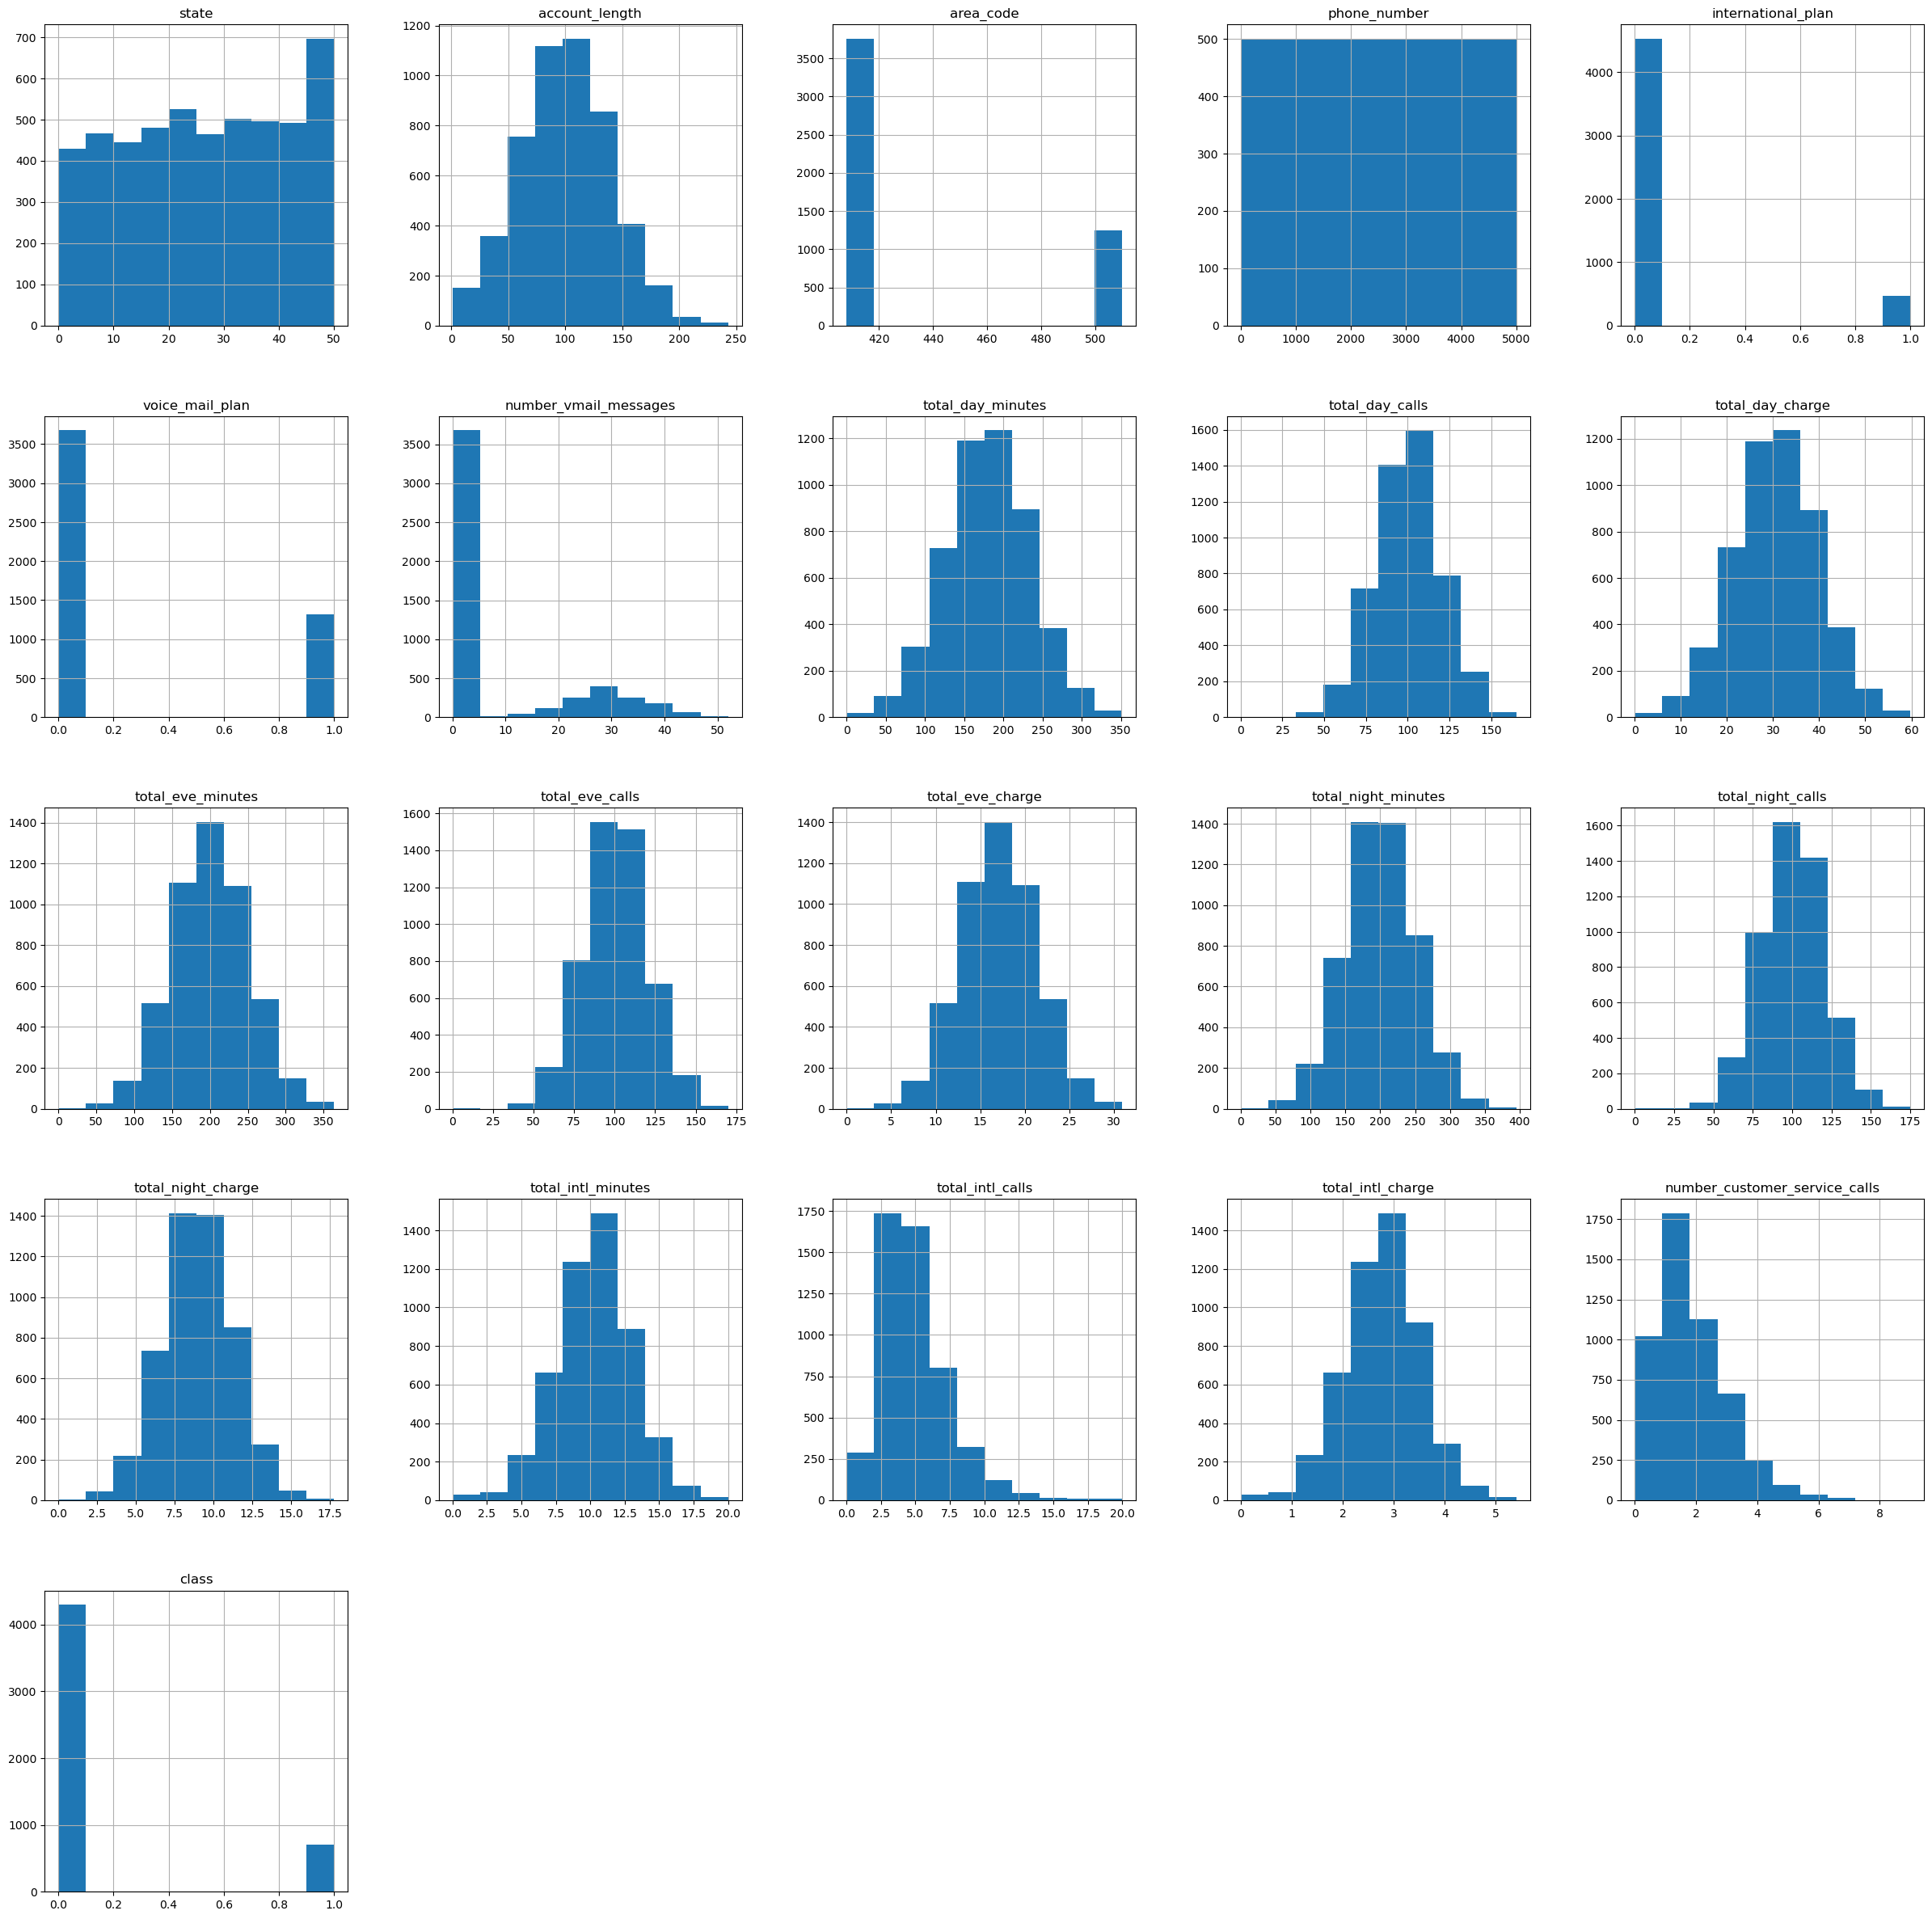

In [9]:
# Build histogram for all features
telecom_df.hist(figsize = (30, 30))
plt.show()

In [10]:
# Get the number of TRUE churned and FALSE churned
# 1 -> Customer churned (stopped using the service)
# 0 -> Customer did not churn (still using the service)
telecom_df["class"].value_counts()

class
0    4293
1     707
Name: count, dtype: int64

<Axes: ylabel='count'>

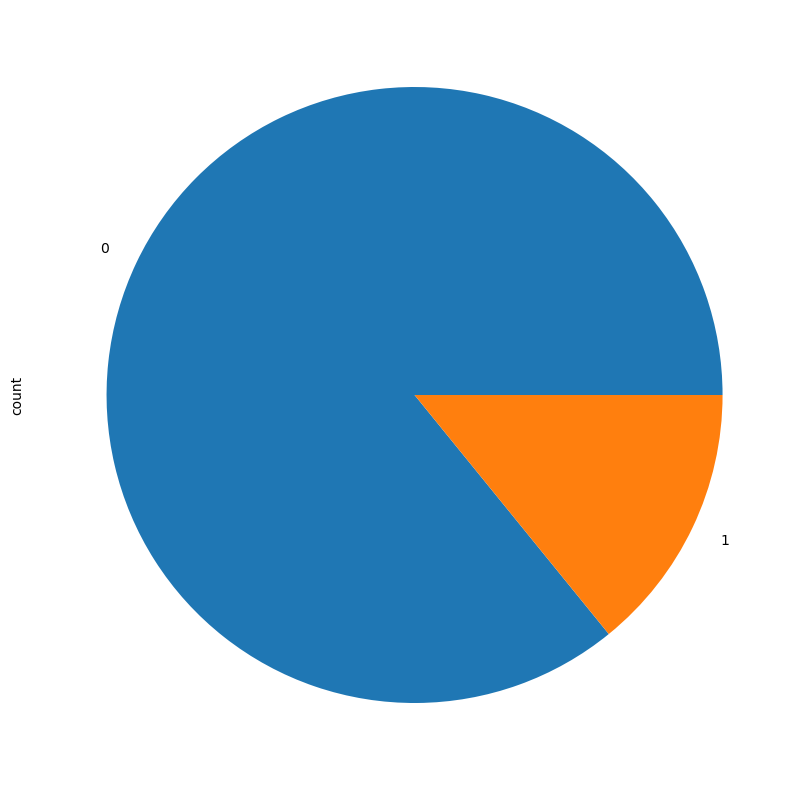

In [11]:
# Build a Pie Chart to see the churn data distribution
plt.figure(figsize = [10, 10])
telecom_df["class"].value_counts().plot(kind='pie')

In [12]:
# Check the Features Correlation
telecom_df.corr()

,state,account_length,area_code,phone_number,international_plan,voice_mail_plan,number_vmail_messages,total_day_minutes,total_day_calls,total_day_charge,...,total_eve_calls,total_eve_charge,total_night_minutes,total_night_calls,total_night_charge,total_intl_minutes,total_intl_calls,total_intl_charge,number_customer_service_calls,class
state,1.000000,0.010334,0.013858,0.017054,0.007422,-0.030075,-0.027282,0.007334,-0.008166,0.007334,...,-0.005458,0.003896,0.009538,-0.001699,0.009532,-0.009313,0.009898,-0.009322,-0.012997,0.006946
account_length,0.010334,1.000000,-0.018054,0.004918,0.014681,-0.006650,-0.014575,-0.001017,0.028240,-0.001019,...,0.009143,-0.009587,0.000668,-0.007825,0.000656,0.001291,0.014277,0.001292,-0.001445,0.021203
area_code,0.013858,-0.018054,1.000000,-0.011648,0.032107,-0.003006,-0.003399,-0.019118,-0.019314,-0.019119,...,-0.012300,0.007114,0.002084,0.014657,0.002070,-0.004154,-0.013623,-0.004219,0.020921,0.010195
phone_number,0.017054,0.004918,-0.011648,1.000000,0.010463,0.014384,0.010649,0.002420,-0.012911,0.002415,...,0.022450,-0.006805,0.008814,0.012723,0.008806,-0.008109,-0.024928,-0.008056,0.028258,0.012371
international_plan,0.007422,0.014681,0.032107,0.010463,1.000000,0.009054,0.011947,0.028138,0.008102,0.028141,...,0.002505,0.021234,-0.026508,0.005623,-0.026510,0.031799,0.004493,0.031751,-0.012974,0.259123
voice_mail_plan,-0.030075,-0.006650,-0.003006,0.014384,0.009054,1.000000,0.954508,0.002059,-0.001735,0.002056,...,-0.005916,0.023332,0.005524,0.009176,0.005522,0.004116,-0.007525,0.004165,-0.014453,-0.110698
number_vmail_messages,-0.027282,-0.014575,-0.003399,0.010649,0.011947,0.954508,1.000000,0.005381,0.000883,0.005377,...,-0.003954,0.019496,0.005541,0.002676,0.005535,0.002463,0.000124,0.002505,-0.007086,-0.097633
total_day_minutes,0.007334,-0.001017,-0.019118,0.002420,0.028138,0.002059,0.005381,1.000000,0.001935,1.000000,...,0.008128,-0.010760,0.011799,0.004236,0.011783,-0.019486,-0.001303,-0.019415,0.002733,0.207705
total_day_calls,-0.008166,0.028240,-0.019314,-0.012911,0.008102,-0.001735,0.000883,0.001935,1.000000,0.001936,...,0.003754,-0.000695,0.002804,-0.008308,0.002802,0.013097,0.010893,0.013161,-0.010739,0.016130
total_day_charge,0.007334,-0.001019,-0.019119,0.002415,0.028141,0.002056,0.005377,1.000000,0.001936,1.000000,...,0.008129,-0.010757,0.011801,0.004235,0.011785,-0.019490,-0.001307,-0.019419,0.002726,0.207700


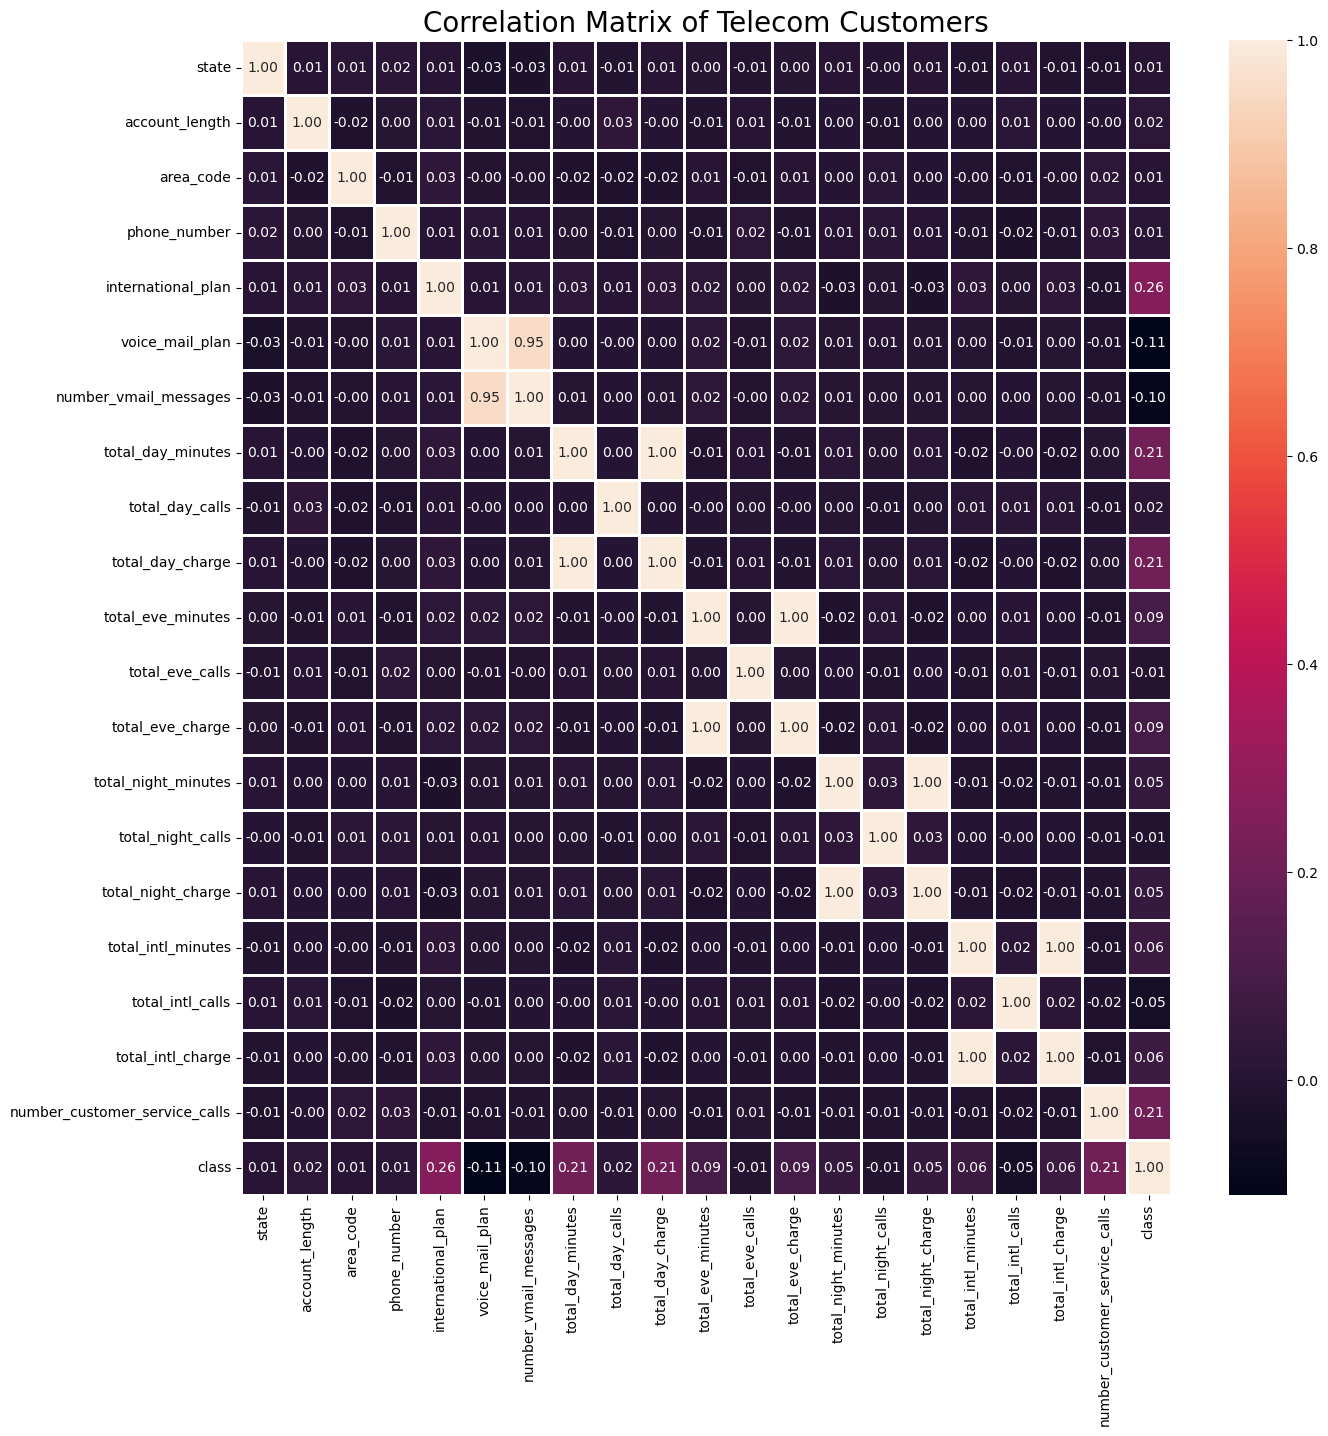

In [13]:
# Build the Correlation Matrix
corr_matrix = telecom_df.corr()
plt.figure(figsize = (15, 15))
cm = sns.heatmap(corr_matrix,
               linewidths = 1,
               annot = True,
               fmt = ".2f")
plt.title("Correlation Matrix of Telecom Customers", fontsize = 20)
plt.show()

# It is clearly visible that "voice_mail_plan" and "number_vmail_messages" are highly correlated.
# It is also clearly visible that "total day charge" and "total day minutes" are highly correlated.

/var/folders/t7/ysyk1bxd7sjgcsxwz34swgf40000gn/T/ipykernel_71458/1379135658.py:2: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  ax = sns.kdeplot(telecom_df.total_day_charge[(telecom_df["class"] == 0)],
/var/folders/t7/ysyk1bxd7sjgcsxwz34swgf40000gn/T/ipykernel_71458/1379135658.py:4: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  ax = sns.kdeplot(telecom_df.total_day_charge[(telecom_df["class"] == 1)],


Text(0.5, 1.0, 'Distribution of day charges by churn')

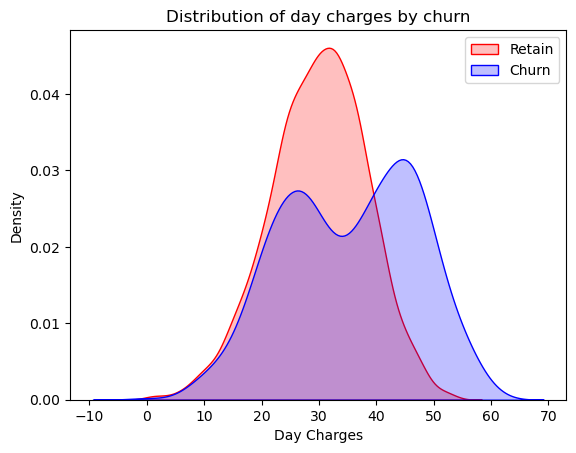

In [14]:
# Churn based on day charges
ax = sns.kdeplot(telecom_df.total_day_charge[(telecom_df["class"] == 0)],
               color = "Red", shade = True)
ax = sns.kdeplot(telecom_df.total_day_charge[(telecom_df["class"] == 1)],
               color = "Blue", shade = True)

ax.legend(["Retain", "Churn"], loc = "upper right")
ax.set_ylabel("Density")
ax.set_xlabel("Day Charges")
ax.set_title("Distribution of day charges by churn")
# To suppress all warnings
#import warnings
#warnings.filterwarnings("ignore")

/var/folders/t7/ysyk1bxd7sjgcsxwz34swgf40000gn/T/ipykernel_71458/1606889533.py:2: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  ax = sns.kdeplot(telecom_df.total_eve_charge[(telecom_df["class"] == 0)],
/var/folders/t7/ysyk1bxd7sjgcsxwz34swgf40000gn/T/ipykernel_71458/1606889533.py:4: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  ax = sns.kdeplot(telecom_df.total_eve_charge[(telecom_df["class"] == 1)],


Text(0.5, 1.0, 'Distribution of evening charges by churn')

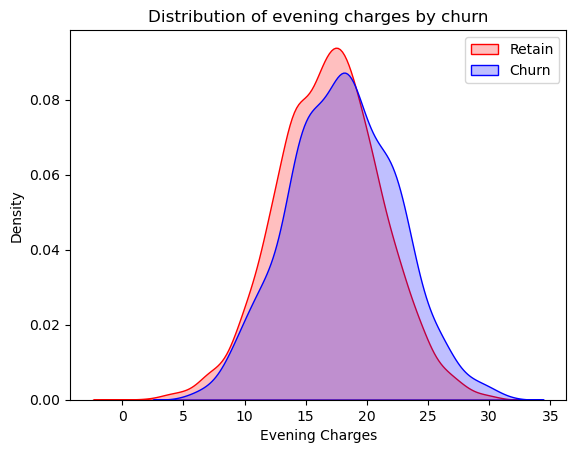

In [15]:
# Churn by evening charges (optional)
ax = sns.kdeplot(telecom_df.total_eve_charge[(telecom_df["class"] == 0)],
               color = "Red", shade = True)
ax = sns.kdeplot(telecom_df.total_eve_charge[(telecom_df["class"] == 1)],
               color = "Blue", shade = True)

ax.legend(["Retain", "Churn"], loc = "upper right")
ax.set_ylabel("Density")
ax.set_xlabel("Evening Charges")
ax.set_title("Distribution of evening charges by churn")

# #3: IDENTIFY FEATURE IMPORTANCE & PREPARE DATA BEFORE MODEL TRAINING

In [16]:
# Unnecessary features can slow down training speed, reduce model interpretability, and hurt generalization performance on test data.
# Therefore, identifying and selecting the most useful features in the dataset is very important.
# Assign input features to X and the output (Churn) to y.

X = telecom_df.drop(["class", "area_code", "phone_number"], axis = "columns") # area_code and phone_number features are irrelevant to proceed further to train the model
y = telecom_df["class"]

In [17]:
X.shape

(5000, 18)

In [18]:
y.shape

(5000,)

In [19]:
# Split the dataset into training and testing sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 150)

In [20]:
X_train.shape

(3500, 18)

In [21]:
X_test.shape

(1500, 18)

In [22]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()
rf.fit(X_train, y_train.values.ravel())

RandomForestClassifier()

In [23]:
# Get feature importance scores
# The importance score shows how strongly that feature affects the model’s output.
# High score → strongly influences the prediction
# Low score → has little or no effect on prediction

rf.feature_importances_

array([0.02403491, 0.02873589, 0.07040519, 0.02279091, 0.02563759,
       0.14782452, 0.02841433, 0.14599865, 0.06415535, 0.02331269,
       0.06057562, 0.03841318, 0.02744153, 0.03841796, 0.03907551,
       0.05271032, 0.04595889, 0.11609694])

In [24]:
X.columns

Index(['state', 'account_length', 'international_plan', 'voice_mail_plan',
       'number_vmail_messages', 'total_day_minutes', 'total_day_calls',
       'total_day_charge', 'total_eve_minutes', 'total_eve_calls',
       'total_eve_charge', 'total_night_minutes', 'total_night_calls',
       'total_night_charge', 'total_intl_minutes', 'total_intl_calls',
       'total_intl_charge', 'number_customer_service_calls'],
      dtype='object')

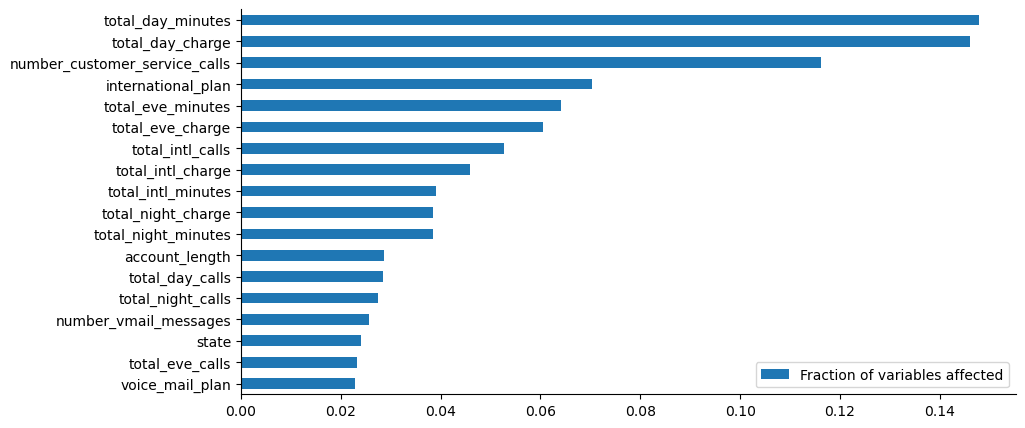

In [25]:
# Plot feature importance

feat_scores= pd.DataFrame({"Fraction of variables affected" : rf.feature_importances_},index = X.columns)
feat_scores= feat_scores.sort_values(by = "Fraction of variables affected")
feat_scores.plot(kind = "barh", figsize = (10, 5))
sns.despine()

In [26]:
#The chart above was generated by the Random Forest algorithm.
#The chart shows that "total_day_minutes" is at the top of the list of important features, followed by "total_day_charge", and so on.

# #4: TRAIN AND EVALUATE THE LOGISTIC REGRESSION CLASSIFICATION MODEL

In [27]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

model_LR = LogisticRegression()

model_LR.fit(X_train, y_train)

/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [28]:
y_predict = model_LR.predict(X_test)

In [29]:
y_predict

array([0, 0, 0, ..., 0, 0, 0])

In [30]:
print(classification_report(y_test, y_predict))
# Precision is the ratio of TP / (TP + FP)
# Recall is the ratio of TP / (TP + FN)
# The F-beta score can be interpreted as the weighted harmonic mean of precision and recall
# The F-beta score reaches its best value at 1 and worst value at 0.

              precision    recall  f1-score   support

           0       0.87      0.98      0.93      1299
           1       0.44      0.08      0.14       201

    accuracy                           0.86      1500
   macro avg       0.65      0.53      0.53      1500
weighted avg       0.82      0.86      0.82      1500



# #5: TRAIN AND EVALUATE THE SUPPORT VECTOR MACHINE CLASSIFICATION MODEL


In [31]:
from sklearn.calibration import CalibratedClassifierCV # For probability score output
from sklearn.svm import LinearSVC # Import Linear Support Vector Classifier (SVM with linear kernel)

# Initialize a Linear Support Vector Classifier
# max_iter=100000 increases the number of iterations to ensure convergence during training
model_svc = LinearSVC(max_iter=100000)

# CalibratedClassifierCV performs probability estimates (predict_proba)
model_svm = CalibratedClassifierCV(model_svc)

# Fit (train) the calibrated SVM model on the training data
model_svm.fit(X_train, y_train)

CalibratedClassifierCV(estimator=LinearSVC(max_iter=100000))

In [32]:
# Use the trained SVM model to predict class labels for the test dataset
y_predict = model_svm.predict(X_test)

In [33]:
# Print a detailed classification report comparing true vs. predicted labels
# This includes Precision, Recall, F1-score, and Support for each class
print(classification_report(y_test, y_predict))

              precision    recall  f1-score   support

           0       0.89      0.97      0.93      1299
           1       0.48      0.19      0.27       201

    accuracy                           0.86      1500
   macro avg       0.68      0.58      0.60      1500
weighted avg       0.83      0.86      0.84      1500



<Axes: >

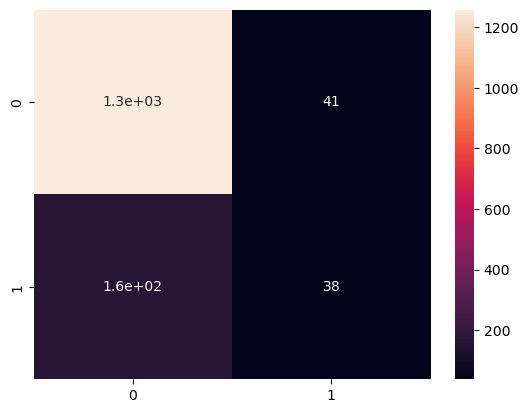

In [34]:
# Compute the confusion matrix to visualize how many predictions were correct or incorrect
cm = confusion_matrix(y_test, y_predict)
# Plot the confusion matrix as a heatmap for better visualization
sns.heatmap(cm, annot = True)

#  #6: TRAIN AND EVALUATE THE RANDOM FOREST CLASSIFICATION MODEL

In [35]:
from sklearn.ensemble import RandomForestClassifier

model_rf = RandomForestClassifier()
model_rf.fit(X_train, y_train)

RandomForestClassifier()

In [36]:
y_predict = model_rf.predict(X_test)

In [37]:
print(classification_report(y_test, y_predict))

              precision    recall  f1-score   support

           0       0.96      0.99      0.98      1299
           1       0.94      0.74      0.82       201

    accuracy                           0.96      1500
   macro avg       0.95      0.86      0.90      1500
weighted avg       0.96      0.96      0.96      1500



<Axes: >

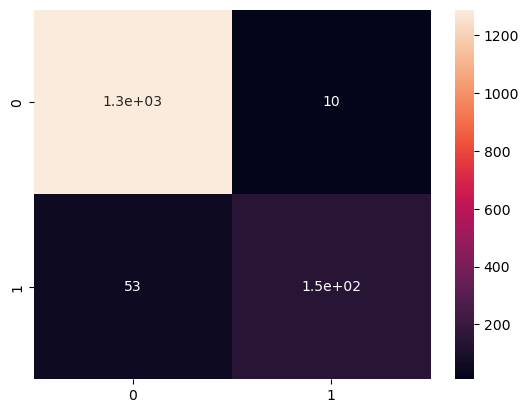

In [38]:
cm = confusion_matrix(y_test, y_predict)
sns.heatmap(cm, annot = True)

# #7: TRAIN AND EVALUATE THE K-NEAREST NEIGHBOR (KNN) MODEL

In [39]:
from sklearn.neighbors import KNeighborsClassifier

model_knn = KNeighborsClassifier()
model_knn.fit(X_train, y_train)

KNeighborsClassifier()

In [40]:
y_predict = model_knn.predict(X_test)

In [41]:
print(classification_report(y_test, y_predict))

              precision    recall  f1-score   support

           0       0.89      0.98      0.94      1299
           1       0.67      0.25      0.37       201

    accuracy                           0.88      1500
   macro avg       0.78      0.62      0.65      1500
weighted avg       0.86      0.88      0.86      1500



<Axes: >

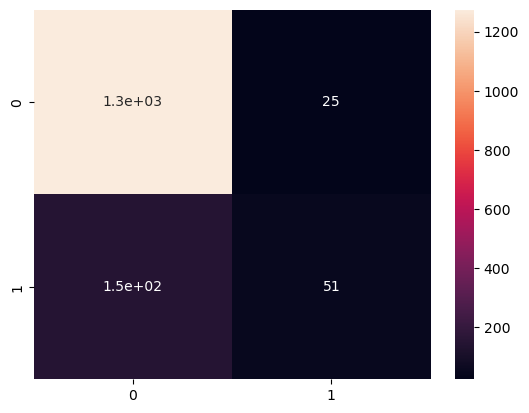

In [42]:
cm = confusion_matrix(y_test, y_predict)
sns.heatmap(cm, annot = True)

# #8:  TRAIN AND EVALUATE THE NAIVE BAYES CLASSIFICATION MODEL

In [43]:
from sklearn.naive_bayes import GaussianNB

In [44]:
model_gnb = GaussianNB()
model_gnb.fit(X_train, y_train)

GaussianNB()

In [45]:
y_predict = model_gnb.predict(X_test)

In [46]:
from sklearn.metrics import classification_report, confusion_matrix

In [47]:
print(classification_report(y_test, y_predict))

              precision    recall  f1-score   support

           0       0.93      0.93      0.93      1299
           1       0.53      0.52      0.52       201

    accuracy                           0.87      1500
   macro avg       0.73      0.72      0.72      1500
weighted avg       0.87      0.87      0.87      1500



<Axes: >

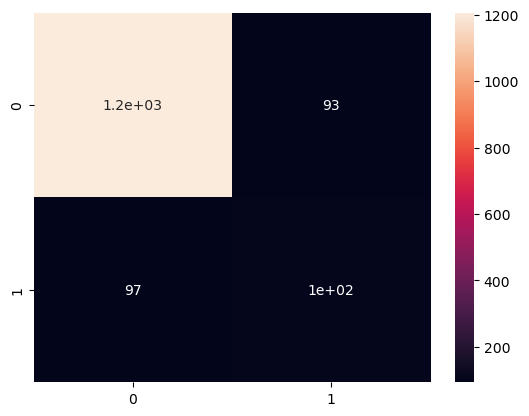

In [48]:
cm = confusion_matrix(y_test, y_predict)
sns.heatmap(cm, annot = True)

#  #9: PLOT THE ROC CURVE FOR ALL TRAINED MODELS

Check this out: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.roc_curve.html

In [49]:
model_LR.predict_proba(X_test)
# The first element is the probability that the output will be 0
# The second element is the probability that the output will be 1

array([[0.96986417, 0.03013583],
       [0.91515853, 0.08484147],
       [0.89314393, 0.10685607],
       ...,
       [0.91960037, 0.08039963],
       [0.944382  , 0.055618  ],
       [0.97313351, 0.02686649]])

In [50]:
# Selecting [:, 1] extracts only the probabilities of the positive class (class = 1)
model_LR.predict_proba(X_test)[:, 1]

array([0.03013583, 0.08484147, 0.10685607, ..., 0.08039963, 0.055618  ,
       0.02686649])

In [51]:
y_test

4827    0
1793    0
2957    0
4218    0
2188    0
       ..
4230    1
3824    0
262     0
1100    0
4359    0
Name: class, Length: 1500, dtype: int64

In [52]:
# Calculate the False Positive Rate (FPR), True Positive Rate (TPR), and threshold values
# for the ROC curve of the Logistic Regression model

# metrics.roc_curve() compares the true labels (y_test) with the predicted probabilities
#   - y_test: the actual class labels from the test set
#   - model_LR.predict_proba(X_test)[:, 1]: the predicted probability of the positive class (class = 1)
#   - pos_label=1: indicates that the label "1" represents the positive class

# The function returns three arrays:
#   fpr1   → False Positive Rate values at different thresholds
#   tpr1   → True Positive Rate (Recall) values at different thresholds
#   thresh1 → The threshold values used to compute FPR and TPR

fpr1, tpr1, thresh1 = metrics.roc_curve(y_test, model_LR.predict_proba(X_test)[:, 1], pos_label= 1)

In [53]:
fpr1

array([0.00000000e+00, 7.69822941e-04, 7.69822941e-04, 1.53964588e-03,
       1.53964588e-03, 3.07929176e-03, 3.07929176e-03, 3.84911470e-03,
       3.84911470e-03, 5.38876059e-03, 5.38876059e-03, 6.92840647e-03,
       6.92840647e-03, 8.46805235e-03, 8.46805235e-03, 1.15473441e-02,
       1.15473441e-02, 1.30869900e-02, 1.30869900e-02, 1.38568129e-02,
       1.38568129e-02, 1.46266359e-02, 1.46266359e-02, 1.61662818e-02,
       1.61662818e-02, 1.69361047e-02, 1.69361047e-02, 2.23248653e-02,
       2.23248653e-02, 2.38645112e-02, 2.38645112e-02, 2.46343341e-02,
       2.46343341e-02, 2.92532717e-02, 2.92532717e-02, 3.07929176e-02,
       3.07929176e-02, 3.46420323e-02, 3.46420323e-02, 4.08006159e-02,
       4.08006159e-02, 4.15704388e-02, 4.15704388e-02, 4.23402617e-02,
       4.23402617e-02, 4.54195535e-02, 4.54195535e-02, 4.61893764e-02,
       4.61893764e-02, 4.69591994e-02, 4.69591994e-02, 4.92686682e-02,
       4.92686682e-02, 5.00384911e-02, 5.00384911e-02, 5.08083141e-02,
      

In [54]:
tpr1

array([0.        , 0.        , 0.00497512, 0.00497512, 0.00995025,
       0.00995025, 0.01492537, 0.01492537, 0.0199005 , 0.0199005 ,
       0.02487562, 0.02487562, 0.03482587, 0.03482587, 0.039801  ,
       0.039801  , 0.04477612, 0.04477612, 0.04975124, 0.04975124,
       0.05472637, 0.05472637, 0.06467662, 0.06467662, 0.07960199,
       0.07960199, 0.08955224, 0.08955224, 0.09452736, 0.09452736,
       0.10447761, 0.10447761, 0.10945274, 0.10945274, 0.11940299,
       0.11940299, 0.12437811, 0.12437811, 0.12935323, 0.12935323,
       0.13432836, 0.13432836, 0.13930348, 0.13930348, 0.14427861,
       0.14427861, 0.15422886, 0.15422886, 0.16915423, 0.16915423,
       0.17910448, 0.17910448, 0.18905473, 0.18905473, 0.19900498,
       0.19900498, 0.2039801 , 0.2039801 , 0.20895522, 0.20895522,
       0.21393035, 0.21393035, 0.21890547, 0.21890547, 0.23880597,
       0.23880597, 0.24378109, 0.24378109, 0.24875622, 0.24875622,
       0.25373134, 0.25373134, 0.25870647, 0.25870647, 0.26368

In [55]:
thresh1

array([       inf, 0.82533873, 0.8059377 , 0.77327804, 0.73324926,
       0.72368865, 0.7151866 , 0.70525696, 0.70084918, 0.66843445,
       0.6639487 , 0.66351115, 0.64717031, 0.62774216, 0.62750091,
       0.58917072, 0.58853215, 0.56835818, 0.56660332, 0.55471503,
       0.54807602, 0.54768558, 0.53347029, 0.52778324, 0.5159902 ,
       0.50735773, 0.4999648 , 0.47833656, 0.47682753, 0.47286313,
       0.46392722, 0.45999791, 0.45999497, 0.44717556, 0.44176641,
       0.43720987, 0.43495676, 0.41739064, 0.41124297, 0.39777307,
       0.39775278, 0.39696203, 0.39678058, 0.39560445, 0.39458779,
       0.38896059, 0.38544385, 0.38394038, 0.37869357, 0.37857642,
       0.37581751, 0.37371685, 0.36945458, 0.3692236 , 0.36790201,
       0.36718455, 0.36651169, 0.36631574, 0.36551217, 0.36218425,
       0.36195855, 0.35763732, 0.35755596, 0.35428934, 0.35163277,
       0.34761137, 0.34527292, 0.34295729, 0.34161727, 0.33629551,
       0.33549186, 0.33139082, 0.33058242, 0.33046154, 0.32973

In [56]:
# ROC
from sklearn.metrics import roc_curve

fpr1, tpr1, thresh1 = roc_curve(y_test, model_LR.predict_proba(X_test)[:, 1], pos_label = 1)
fpr2, tpr2, thresh2 = roc_curve(y_test, model_svm.predict_proba(X_test)[:, 1], pos_label = 1)
fpr3, tpr3, thresh3 = roc_curve(y_test, model_rf.predict_proba(X_test)[:, 1], pos_label = 1)
fpr4, tpr4, thresh4 = roc_curve(y_test, model_knn.predict_proba(X_test)[:, 1], pos_label = 1)
fpr5, tpr5, thresh5 = roc_curve(y_test, model_gnb.predict_proba(X_test)[:, 1], pos_label = 1)


In [57]:
# AUC

from sklearn.metrics import roc_auc_score

auc_score1 = roc_auc_score(y_test, model_LR.predict_proba(X_test)[:, 1])
auc_score2 = roc_auc_score(y_test, model_svm.predict_proba(X_test)[:, 1])
auc_score3 = roc_auc_score(y_test, model_rf.predict_proba(X_test)[:, 1])
auc_score4 = roc_auc_score(y_test, model_knn.predict_proba(X_test)[:, 1])
auc_score5 = roc_auc_score(y_test, model_gnb.predict_proba(X_test)[:, 1])

print("Logistic Regression: ", auc_score1) # Logistic Regression
print("Support Vector Machine: ", auc_score2) # Support Vector Machine
print("Random Forest: ", auc_score3) # Random Forest
print("K-Nearest Neighbors: ", auc_score4) # K-Nearest Neighbors
print("Naive Bayes: ", auc_score5) # Naive Bayes

Logistic Regression:  0.6950428764568228
Support Vector Machine:  0.7988004549998278
Random Forest:  0.9115929206929172
K-Nearest Neighbors:  0.6563123566156898
Naive Bayes:  0.8270158062650564


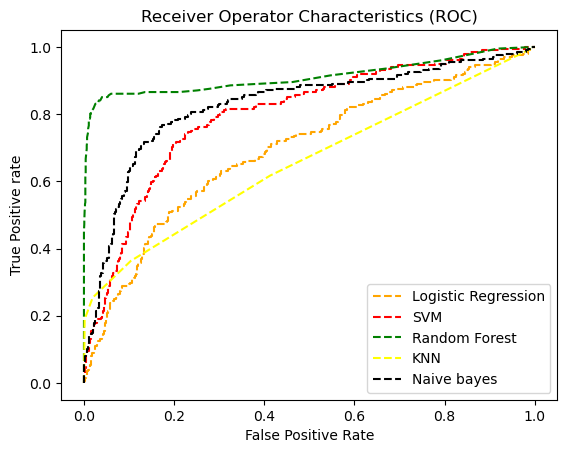

In [58]:
plt.plot(fpr1, tpr1, linestyle = "--", color = "orange", label = "Logistic Regression")
plt.plot(fpr2, tpr2, linestyle = "--", color = "red", label = "SVM")
plt.plot(fpr3, tpr3, linestyle = "--", color = "green", label = "Random Forest")
plt.plot(fpr4, tpr4, linestyle = "--", color = "yellow", label = "KNN")
plt.plot(fpr5, tpr5, linestyle = "--", color = "black", label = "Naive bayes")

plt.title('Receiver Operator Characteristics (ROC)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive rate')

plt.legend(loc = 'best')
plt.savefig('ROC', dpi = 300)
plt.show()

The chart shows that the **Random Forest algorithm** produces the **best AUC**. Therefore, it is clear that the **Random Forest model** performs better in classifying telecommunication customers who **churn or retain**.


Among all the trained models, the Random Forest Classifier algorithm produced the highest Area Under the ROC Curve (AUC).

The following scores are the results of the Random Forest Classifier model:

1.   Accuracy: ~96%
2.   Precision: ~96% for customers labeled as retained and ~93% for customers labeled as churned
3.   Recall: ~99% for customers labeled as retained and ~76% for customers labeled as churned

Note: We can further improve this model by using the Grid Search method.

Additional literature for Grid Search:: https://machinelearningmastery.com/hyperparameter-optimization-with-random-search-and-grid-search/



---



# INDIVIDUAL EXERCISE

The dataset contains information about **default payments**, **demographic factors**, **credit data**, **payment history**, and **billing statements** of **credit card clients in Taiwan** from **April 2005 to September 2005**.

There are **25 variables:**


- ID: ID of each client
- LIMIT_BAL: Amount of given credit in NT dollars (includes individual and family/supplementary credit
- SEX: Gender (1=male, 2=female)
- EDUCATION: (1=graduate school, 2=university, 3=high school, 4=others, 5=unknown, 6=unknown)
- MARRIAGE: Marital status (1=married, 2=single, 3=others)
- AGE: Age in years
- PAY_0: Repayment status in September, 2005 (-1=pay duly, 1=payment delay for one month, 2=payment delay for two months, ... 8=payment delay for eight months, 9=payment delay for nine months and above)
- PAY_2: Repayment status in August, 2005 (scale same as above)
- PAY_3: Repayment status in July, 2005 (scale same as above)
- PAY_4: Repayment status in June, 2005 (scale same as above)
- PAY_5: Repayment status in May, 2005 (scale same as above)
- PAY_6: Repayment status in April, 2005 (scale same as above)
- BILL_AMT1: Amount of bill statement in September, 2005 (NT dollar)
- BILL_AMT2: Amount of bill statement in August, 2005 (NT dollar)
- BILL_AMT3: Amount of bill statement in July, 2005 (NT dollar)
- BILL_AMT4: Amount of bill statement in June, 2005 (NT dollar)
- BILL_AMT5: Amount of bill statement in May, 2005 (NT dollar)
- BILL_AMT6: Amount of bill statement in April, 2005 (NT dollar)
- PAY_AMT1: Amount of previous payment in September, 2005 (NT dollar)
- PAY_AMT2: Amount of previous payment in August, 2005 (NT dollar)
- PAY_AMT3: Amount of previous payment in July, 2005 (NT dollar)
- PAY_AMT4: Amount of previous payment in June, 2005 (NT dollar)
- PAY_AMT5: Amount of previous payment in May, 2005 (NT dollar)
- PAY_AMT6: Amount of previous payment in April, 2005 (NT dollar)
default.payment.next.month: Default payment (1=yes, 0=no)


**Complete the following tasks:**

1. Import data "UCI_Credit_Card.csv"
2. Conduct EDA (Exploratory Data Analysis) and visualization. Feel free to choose the data visualizations you find most appropriate.
3. Prepare the data for model training and split it into training and testing sets.
4. Train and evaluate an XGBoost classification model (optional).
5. Train and evaluate a Support Vector Machine (SVM) classification model.
6. Train and evaluate a Naive Bayes classification model.
7. Train and evaluate a Logistic Regression classification model.
8. Train and evaluate a Random Forest classification model.
9. Train and evaluate a K-Nearest Neighbors (KNN) classification model.
10. Plot the ROC curves for all models and calculate their AUC values.
11. Determine which model performs best.








Any publications based on this dataset should acknowledge the following:

Lichman, M. (2013). UCI Machine Learning Repository [http://archive.ics.uci.edu/ml]. Irvine, CA: University of California, School of Information and Computer Science.

The original dataset can be found here at the UCI Machine Learning Repository.

